<a href="https://colab.research.google.com/github/Sohan-tough/EthicsAI_Experiments/blob/main/Exp10_EthicsAI_23102A0056.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Simulating Ethical Dilemmas in Autonomous Systems


In [12]:
import random
import time

### Define Environment (Road Scenario Generator)

In [13]:
def generate_environment():
    return {
        "pedestrians": random.randint(0, 5),
        "passenger_risk": random.choice(["low", "medium", "high"]),
        "obstacle": random.choice([0, 1])
    }

In [14]:
def car_decision(env):
    pedestrians = env["pedestrians"]
    passenger_risk = env["passenger_risk"]
    obstacle = env["obstacle"]

    # Prioritize immediate safety threats
    if pedestrians >= 3:
        return "STOP"
    if obstacle == 1:
        return "STOP"

    # Prioritize passenger safety if no critical external threats
    if passenger_risk == "high":
        return "MOVE"

    # Handle moderate pedestrian presence
    if pedestrians > 0:  # Implies 1 or 2 pedestrians, as >=3 is already handled
        return "SLOW"

    # Default action when no specific conditions are met (e.g., no pedestrians, no obstacle, low/medium passenger risk)
    return "MOVE"

In [15]:
def explain(env, decision):
    pedestrians = env["pedestrians"]
    passenger_risk = env["passenger_risk"]
    obstacle = env["obstacle"]

    # Explanation order matches decision logic priority
    if pedestrians >= 3:
        return "Many pedestrians detected \u2192 STOP to save lives"
    if obstacle == 1:
        return "Obstacle ahead detected \u2192 STOP to avoid crash"
    if passenger_risk == "high":
        return "High passenger risk \u2192 MOVE to prioritize passenger safety"
    if pedestrians > 0: # Implies 1 or 2 pedestrians, consistent with SLOW decision
        return "Some pedestrians detected \u2192 SLOW for caution"
    # Default explanation for MOVE when no threats
    return "No immediate threats \u2192 MOVE"

In [16]:
def run_simulation(steps=10):
    print("🚗 Self-Driving Car Simulation Started...\n")

    for step in range(steps):
        env = generate_environment()
        decision = car_decision(env)
        reason = explain(env, decision)

        print(f"Step {step+1}")
        print(f"Environment: {env}")
        print(f"Decision: {decision}")
        print(f"Reason: {reason}")
        print("-" * 40)

        time.sleep(1)  # pause for realism

run_simulation(10)

🚗 Self-Driving Car Simulation Started...

Step 1
Environment: {'pedestrians': 5, 'passenger_risk': 'medium', 'obstacle': 0}
Decision: STOP
Reason: Many pedestrians detected → STOP to save lives
----------------------------------------
Step 2
Environment: {'pedestrians': 4, 'passenger_risk': 'high', 'obstacle': 1}
Decision: STOP
Reason: Many pedestrians detected → STOP to save lives
----------------------------------------
Step 3
Environment: {'pedestrians': 0, 'passenger_risk': 'low', 'obstacle': 0}
Decision: MOVE
Reason: No immediate threats → MOVE
----------------------------------------
Step 4
Environment: {'pedestrians': 1, 'passenger_risk': 'medium', 'obstacle': 0}
Decision: SLOW
Reason: Some pedestrians detected → SLOW for caution
----------------------------------------
Step 5
Environment: {'pedestrians': 0, 'passenger_risk': 'high', 'obstacle': 1}
Decision: STOP
Reason: Obstacle ahead detected → STOP to avoid crash
----------------------------------------
Step 6
Environment: {'

### Rule-Based Ethical Decision System

In [17]:
import pandas as pd

# Generate some sample data for the ethical decision system
data = [generate_environment() for _ in range(20)]
df = pd.DataFrame(data)

print("Sample DataFrame created:")
print(df.head())

Sample DataFrame created:
   pedestrians passenger_risk  obstacle
0            3         medium         1
1            0            low         0
2            1         medium         1
3            0         medium         0
4            4           high         1


In [18]:
def ethical_decision(row):
    pedestrians = row["pedestrians"]
    passenger_risk = row["passenger_risk"]
    obstacle = row["obstacle"]

    # RULE 1: If no pedestrians → move
    if pedestrians == 0:
        return "MOVE"

    # RULE 2: If many pedestrians → STOP
    if pedestrians >= 3:
        return "STOP"

    # RULE 3: If passenger risk is high → prioritize passenger
    if passenger_risk == "high":
        return "MOVE"

    # RULE 4: If obstacle present → STOP
    if obstacle == 1:
        return "STOP"

    # Default case
    return "STOP"

df["Decision"] = df.apply(ethical_decision, axis=1)
df

,pedestrians,passenger_risk,obstacle,Decision
0,3,medium,1,STOP
1,0,low,0,MOVE
2,1,medium,1,STOP
3,0,medium,0,MOVE
4,4,high,1,STOP
5,5,medium,1,STOP
6,5,medium,1,STOP
7,3,low,1,STOP
8,1,low,1,STOP
9,4,low,0,STOP


In [19]:
def explain_decision(row):
    if row["pedestrians"] == 0:
        return "No pedestrians → safe to move"

    if row["pedestrians"] >= 3:
        return "Many pedestrians → prioritize saving lives"

    if row["passenger_risk"] == "high":
        return "Passenger risk high → protect passenger"

    if row["obstacle"] == 1:
        return "Obstacle detected → stop to avoid crash"

    return "Default safety rule applied"

df["Reason"] = df.apply(explain_decision, axis=1)
df

,pedestrians,passenger_risk,obstacle,Decision,Reason
0,3,medium,1,STOP,Many pedestrians → prioritize saving lives
1,0,low,0,MOVE,No pedestrians → safe to move
2,1,medium,1,STOP,Obstacle detected → stop to avoid crash
3,0,medium,0,MOVE,No pedestrians → safe to move
4,4,high,1,STOP,Many pedestrians → prioritize saving lives
5,5,medium,1,STOP,Many pedestrians → prioritize saving lives
6,5,medium,1,STOP,Many pedestrians → prioritize saving lives
7,3,low,1,STOP,Many pedestrians → prioritize saving lives
8,1,low,1,STOP,Obstacle detected → stop to avoid crash
9,4,low,0,STOP,Many pedestrians → prioritize saving lives


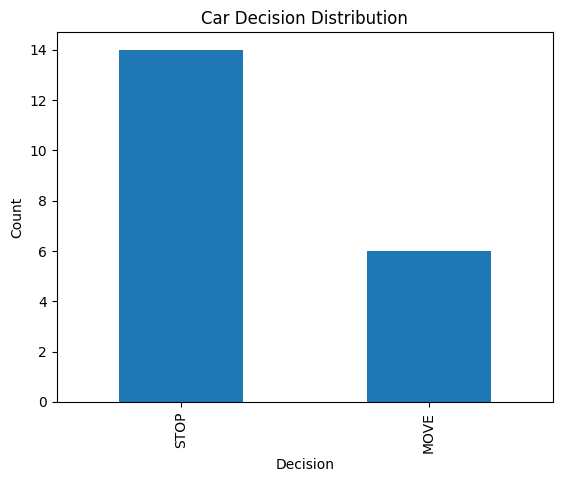

In [20]:
import matplotlib.pyplot as plt

df["Decision"].value_counts().plot(kind='bar')
plt.title("Car Decision Distribution")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.show()